In [1]:
import pandas as pd
from PIL import Image
import os
import sys
import json
import random
import torch
import torch.nn as nn
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import f1_score

In [2]:
%matplotlib inline

In [3]:
# Base Path
base_path = "E://OVGU_NOTES//Machine_Learning_Safety//assignment//Data_set//"

# Exercise 9.4: Visualising the Distribution Shift

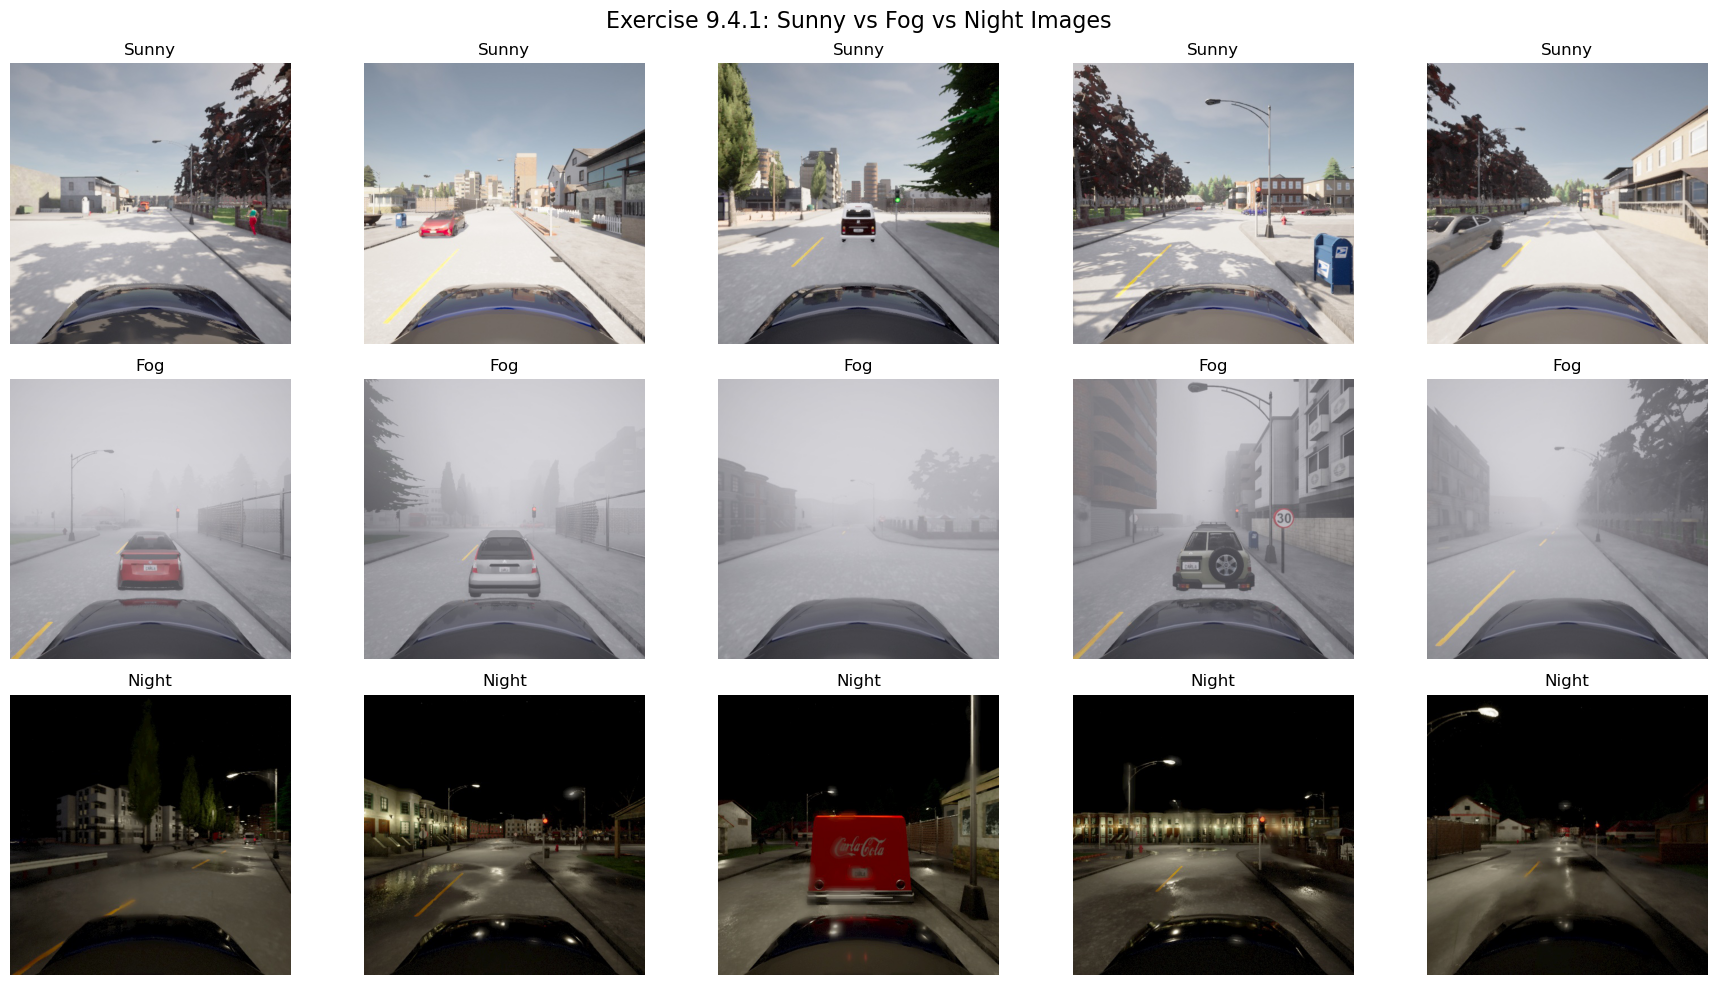

In [4]:
# Display five in-distribution (sunny / daytime) images next to five fog and five night images

sunny_folder = f"{base_path}test//rgb-front"
fog_folder = f"{base_path}test-fog//rgb-front"
night_folder = f"{base_path}test-night//rgb-front"

# Get JPG Images
sunny_images = [f for f in os.listdir(sunny_folder) if f.endswith(".jpg")]
fog_images = [f for f in os.listdir(fog_folder) if f.endswith(".jpg")]
night_images = [f for f in os.listdir(night_folder) if f.endswith(".jpg")]

# Randomly Select 5 Images
sunny_sample = random.sample(sunny_images, 5)
fog_sample = random.sample(fog_images, 5)
night_sample = random.sample(night_images, 5)

# Plot Images
fig, axes = plt.subplots(3, 5, figsize=(18, 10))

# Row 1 → Sunny
for i, img_name in enumerate(sunny_sample):

    img = Image.open(
        os.path.join(sunny_folder, img_name)
    )

    axes[0, i].imshow(img)
    axes[0, i].set_title("Sunny")
    axes[0, i].axis("off")

# Row 2 → Fog
for i, img_name in enumerate(fog_sample):

    img = Image.open(
        os.path.join(fog_folder, img_name)
    )

    axes[1, i].imshow(img)
    axes[1, i].set_title("Fog")
    axes[1, i].axis("off")

# Row 3 → Night
for i, img_name in enumerate(night_sample):

    img = Image.open(
        os.path.join(night_folder, img_name)
    )

    axes[2, i].imshow(img)
    axes[2, i].set_title("Night")
    axes[2, i].axis("off")

plt.suptitle(
    "Exercise 9.4.1: Sunny vs Fog vs Night Images",
    fontsize=16
)

plt.tight_layout()

plt.show()
plt.close("all")

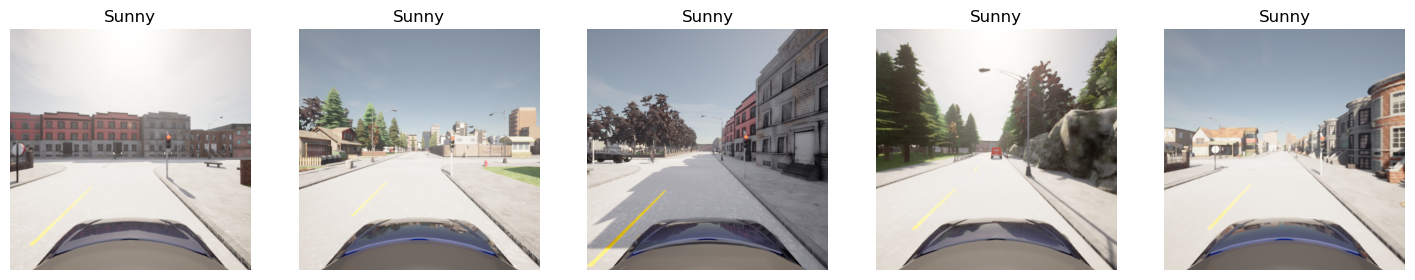

In [5]:
# Also display five images from the different CARLA town. 
test_town_folder = f"{base_path}test//rgb-front"

# Get JPG Images
test_town_images = [f for f in os.listdir(test_town_folder) if f.endswith(".jpg")]

# Randomly Select 5 Images
test_town_sample = random.sample(test_town_images, 5)

# Plot Images
fig, axes = plt.subplots(1, 5, figsize=(18, 10))

# Row 1 → Sunny
for i, img_name in enumerate(test_town_sample):

    img = Image.open(
        os.path.join(test_town_folder, img_name)
    )

    axes[i].imshow(img)
    axes[i].set_title("Sunny")
    axes[i].axis("off")

plt.show()
plt.close("all")

In [6]:
# Compute its AUROC and compare it to the MSP AUROC from Exercise 9.6. For which OOD scenario is the gap largest?


def mean_confidence(
    model,
    csv_path,
    image_folder,
    transform,
    device
):

    df = pd.read_csv(csv_path)

    confidences = []

    for _, row in df.iterrows():

        frame = str(row["frame"]).zfill(6)

        img_path = f"{image_folder}/{frame}.jpg"

        try:

            image = Image.open(img_path).convert("RGB")

            input_tensor = transform(image).unsqueeze(0).to(device)

            with torch.no_grad():

                output = model(input_tensor)

                prob = torch.sigmoid(output).item()

            confidence = max(prob, 1 - prob)

            confidences.append(confidence)

        except:
            continue

    return np.mean(confidences)


In [10]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## Pedestrian Model

In [7]:
# Pedetrian Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_pedestrian = models.resnet18(weights=None)

model_pedestrian.fc = nn.Linear(
    model_pedestrian.fc.in_features,
    1
)

model_pedestrian.load_state_dict(
    torch.load(
        "pedestrian.pth",
        map_location=device
    )
)

model_pedestrian.to(device)
model_pedestrian.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [9]:
ped_test_conf = mean_confidence(
    model_pedestrian,
    f"{base_path}test/labels.csv",
    f"{base_path}test/rgb-front",
    transform,
    device
)

ped_fog_conf = mean_confidence(
    model_pedestrian,
    f"{base_path}test-fog/labels.csv",
    f"{base_path}test-fog/rgb-front",
    transform,
    device
)

ped_night_conf = mean_confidence(
    model_pedestrian,
    f"{base_path}test-night/labels.csv",
    f"{base_path}test-night/rgb-front",
    transform,
    device
)

print("Pedestrian Test :", ped_test_conf)
print("Pedestrian Fog  :", ped_fog_conf)
print("Pedestrian Night:", ped_night_conf)

Pedestrian Test : 0.9680348456231878
Pedestrian Fog  : 0.9517400129139424
Pedestrian Night: 0.9530596700476276


## Vehicle Model

In [11]:
# Vehicle Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vehicle = models.resnet18(weights=None)

model_vehicle.fc = nn.Linear(
    model_vehicle.fc.in_features,
    1
)

model_vehicle.load_state_dict(
    torch.load(
        "vehicle.pth",
        map_location=device
    )
)

model_vehicle.to(device)
model_vehicle.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [12]:
veh_test_conf = mean_confidence(
    model_vehicle,
    f"{base_path}test/labels.csv",
    f"{base_path}test/rgb-front",
    transform,
    device
)

veh_fog_conf = mean_confidence(
    model_vehicle,
    f"{base_path}test-fog/labels.csv",
    f"{base_path}test-fog/rgb-front",
    transform,
    device
)

veh_night_conf = mean_confidence(
    model_vehicle,
    f"{base_path}test-night/labels.csv",
    f"{base_path}test-night/rgb-front",
    transform,
    device
)

print("Vehicle Test :", veh_test_conf)
print("Vehicle Fog  :", veh_fog_conf)
print("Vehicle Night:", veh_night_conf)

Vehicle Test : 0.9055714525028856
Vehicle Fog  : 0.8058541870603545
Vehicle Night: 0.9677254596533668


## Traffic Model

In [13]:
# Traffic Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_traffic = models.resnet18(weights=None)

model_traffic.fc = nn.Linear(
    model_traffic.fc.in_features,
    1
)

model_traffic.load_state_dict(
    torch.load(
        "traffic.pth",
        map_location=device
    )
)

model_traffic.to(device)
model_traffic.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [14]:
traf_test_conf = mean_confidence(
    model_traffic,
    f"{base_path}test/labels.csv",
    f"{base_path}test/rgb-front",
    transform,
    device
)
traf_fog_conf = mean_confidence(
    model_traffic,
    f"{base_path}test-fog/labels.csv",
    f"{base_path}test-fog/rgb-front",
    transform,
    device
)

traf_night_conf = mean_confidence(
    model_traffic,
    f"{base_path}test-night/labels.csv",
    f"{base_path}test-night/rgb-front",
    transform,
    device
)

print("Vehicle Test :", traf_test_conf)
print("Vehicle Fog  :", traf_fog_conf)
print("Vehicle Night:", traf_night_conf)

Vehicle Test : 0.87904393904992
Vehicle Fog  : 0.9082287355049307
Vehicle Night: 0.9087910126868842


# Exercise 9.6: Evaluating the MSP Baseline

In [17]:
#Plot the distribution of OOD scores for in-distribution and OOD images.

def get_msp_scores(
    model,
    csv_path,
    image_folder,
    transform,
    device
):

    df = pd.read_csv(csv_path)

    scores = []

    for _, row in df.iterrows():

        frame = str(row["frame"]).zfill(6)

        img_path = f"{image_folder}/{frame}.jpg"

        try:

            image = Image.open(img_path).convert("RGB")

            input_tensor = transform(image).unsqueeze(0).to(device)

            with torch.no_grad():

                output = model(input_tensor)

                prob = torch.sigmoid(output).item()

            msp = max(prob, 1 - prob)

            scores.append(msp)

        except:
            continue

    return scores

In [18]:
id_scores = get_msp_scores(
    model_pedestrian,
    f"{base_path}test/labels.csv",
    f"{base_path}test/rgb-front",
    transform,
    device
)

In [19]:
fog_scores = get_msp_scores(
    model_pedestrian,
    f"{base_path}test-fog/labels.csv",
    f"{base_path}test-fog/rgb-front",
    transform,
    device
)

night_scores = get_msp_scores(
    model_pedestrian,
    f"{base_path}test-night/labels.csv",
    f"{base_path}test-night/rgb-front",
    transform,
    device
)

town_scores = get_msp_scores(
    model_pedestrian,
    f"{base_path}test-town-01/labels.csv",
    f"{base_path}test-town-01/rgb-front",
    transform,
    device
)

ood_scores = fog_scores + night_scores + town_scores

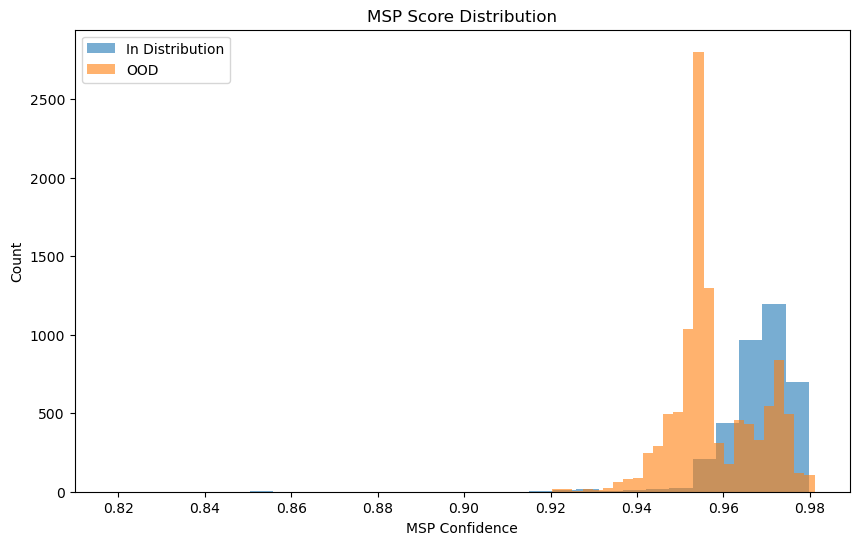

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    id_scores,
    bins=30,
    alpha=0.6,
    label="In Distribution"
)

plt.hist(
    ood_scores,
    bins=30,
    alpha=0.6,
    label="OOD"
)

plt.xlabel("MSP Confidence")
plt.ylabel("Count")

plt.title(
    "MSP Score Distribution"
)

plt.legend()

plt.show()

In [21]:
from sklearn.metrics import roc_auc_score

y_true = (
    [0] * len(id_scores)
    +
    [1] * len(ood_scores)
)

scores = (
    id_scores
    +
    ood_scores
)

# Lower confidence = more OOD
ood_score = [1 - s for s in scores]

auroc = roc_auc_score(
    y_true,
    ood_score
)

print("AUROC =", auroc)

AUROC = 0.7955289737654321


# Exercise 9.7: Feature-Based OOD Detection

In [22]:
feature_extractor = nn.Sequential(
    *list(model_pedestrian.children())[:-1]
)

feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

In [23]:
def extract_features(
    model,
    csv_path,
    image_folder,
    transform,
    device
):

    df = pd.read_csv(csv_path)

    features = []

    for _, row in df.iterrows():

        frame = str(row["frame"]).zfill(6)

        img_path = f"{image_folder}/{frame}.jpg"

        try:

            image = Image.open(img_path).convert("RGB")

            x = transform(image).unsqueeze(0).to(device)

            with torch.no_grad():

                feat = model(x)

                feat = feat.view(-1)

            features.append(
                feat.cpu().numpy()
            )

        except:
            continue

    return np.array(features)

In [24]:
# Validation Features (Reference ID Data)
val_features = extract_features(
    feature_extractor,
    f"{base_path}validation/labels.csv",
    f"{base_path}validation/rgb-front",
    transform,
    device
)

print(val_features.shape)

(3600, 512)


In [25]:
#  Test Feature ID
test_features = extract_features(
    feature_extractor,
    f"{base_path}test/labels.csv",
    f"{base_path}test/rgb-front",
    transform,
    device
)

In [26]:
#  Test Feature Fog
fog_features = extract_features(
    feature_extractor,
    f"{base_path}test-fog/labels.csv",
    f"{base_path}test-fog/rgb-front",
    transform,
    device
)

In [27]:
# Test Feature Night 
night_features = extract_features(
    feature_extractor,
    f"{base_path}test-night/labels.csv",
    f"{base_path}test-night/rgb-front",
    transform,
    device
)

In [29]:
# Test feature Town
town_features = extract_features(
    feature_extractor,
    f"{base_path}test-town-01/labels.csv",
    f"{base_path}test-town-01/rgb-front",
    transform,
    device
)

In [30]:
# Fitting to Knn
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=5
)

knn.fit(val_features)

,n_neighbors,5
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,None


In [31]:
# Larger distance = more OOD
def knn_score(features):

    distances, _ = knn.kneighbors(features)

    return distances.mean(axis=1)

In [32]:
id_scores = knn_score(test_features)

fog_scores = knn_score(fog_features)

night_scores = knn_score(night_features)

town_scores = knn_score(town_features)

In [33]:
# AUROC
from sklearn.metrics import roc_auc_score

ood_scores = np.concatenate([
    fog_scores,
    night_scores,
    town_scores
])

y_true = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(ood_scores))
])

scores = np.concatenate([
    id_scores,
    ood_scores
])

auroc_knn = roc_auc_score(
    y_true,
    scores
)



kNN AUROC = 0.8601727109053499


In [34]:
# For which OOD scenario is the gap largest?

def scenario_auroc(id_scores, ood_scores):

    y_true = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores))
    ])

    scores = np.concatenate([
        id_scores,
        ood_scores
    ])

    return roc_auc_score(
        y_true,
        scores
    )


Fog AUROC: 0.937085725308642
Night AUROC: 0.9847594135802469
Town AUROC: 0.6586729938271605


In [35]:
print("kNN AUROC =", auroc_knn)

print("Fog AUROC:",
      scenario_auroc(id_scores, fog_scores))

print("Night AUROC:",
      scenario_auroc(id_scores, night_scores))

print("Town AUROC:",
      scenario_auroc(id_scores, town_scores))

kNN AUROC = 0.8601727109053499
Fog AUROC: 0.937085725308642
Night AUROC: 0.9847594135802469
Town AUROC: 0.6586729938271605
